In [ ]:
#- Imports e configurações
import warnings
from typing import Dict, Iterable, Optional, Tuple, Sequence

# Bibliotecas especializadas
import missingno as msno
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay
  )
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import GridSearchCV, train_test_split

warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("train.csv")
df.drop(columns=['id'], inplace=True)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,7.32,0
1,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,2.99,0
2,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,175.10,0
3,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,6.10,0
4,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,86.10,0


#Análise Univariada

In [ ]:
# Estatísticas descritivas detalhadas
for var in df.columns:
    print(f"\n📊 {var.upper()}:")
    data = df[var].dropna()

    # Estatísticas básicas
    print(f"  Mean: {data.mean():.2f}")
    print(f"  Median: {data.median():.2f}")
    print(f"  Std: {data.std():.2f}")
    print(f"  Skewness: {stats.skew(data):.2f}")
    print(f"  Kurtosis: {stats.kurtosis(data):.2f}")

    # Outliers (IQR method)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    print(f"  Outliers: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")


📊 TIME:
  Mean: 94885.09
  Median: 84805.00
  Std: 47488.42
  Skewness: -0.04
  Kurtosis: -1.29
  Outliers: 0 (0.0%)

📊 V1:
  Mean: 0.00
  Median: 0.02
  Std: 1.96
  Skewness: -3.31
  Kurtosis: 33.32
  Outliers: 5639 (2.5%)

📊 V2:
  Mean: -0.00
  Median: 0.06
  Std: 1.65
  Skewness: -4.78
  Kurtosis: 103.03
  Outliers: 10774 (4.7%)

📊 V3:
  Mean: -0.00
  Median: 0.18
  Std: 1.52
  Skewness: -2.25
  Kurtosis: 27.28
  Outliers: 2689 (1.2%)

📊 V4:
  Mean: -0.00
  Median: -0.02
  Std: 1.42
  Skewness: 0.69
  Kurtosis: 2.73
  Outliers: 8958 (3.9%)

📊 V5:
  Mean: 0.00
  Median: -0.05
  Std: 1.38
  Skewness: -2.79
  Kurtosis: 245.68
  Outliers: 9805 (4.3%)

📊 V6:
  Mean: -0.00
  Median: -0.27
  Std: 1.33
  Skewness: 1.94
  Kurtosis: 50.65
  Outliers: 18273 (8.0%)

📊 V7:
  Mean: 0.00
  Median: 0.04
  Std: 1.24
  Skewness: 3.15
  Kurtosis: 479.84
  Outliers: 7112 (3.1%)

📊 V8:
  Mean: -0.00
  Median: 0.02
  Std: 1.19
  Skewness: -8.64
  Kurtosis: 227.40
  Outliers: 19214 (8.4%)

📊 V9:
  Mean: 

##Plotagem da distribuição das features do tipo V

Foi escolhido dividir essas features em blocos de 7 para melhorar a visualização

In [ ]:
v_features = [col for col in df.columns if col.startswith('V')]
v_blocks = [v_features[i:i+7] for i in range(0, len(v_features), 7)]

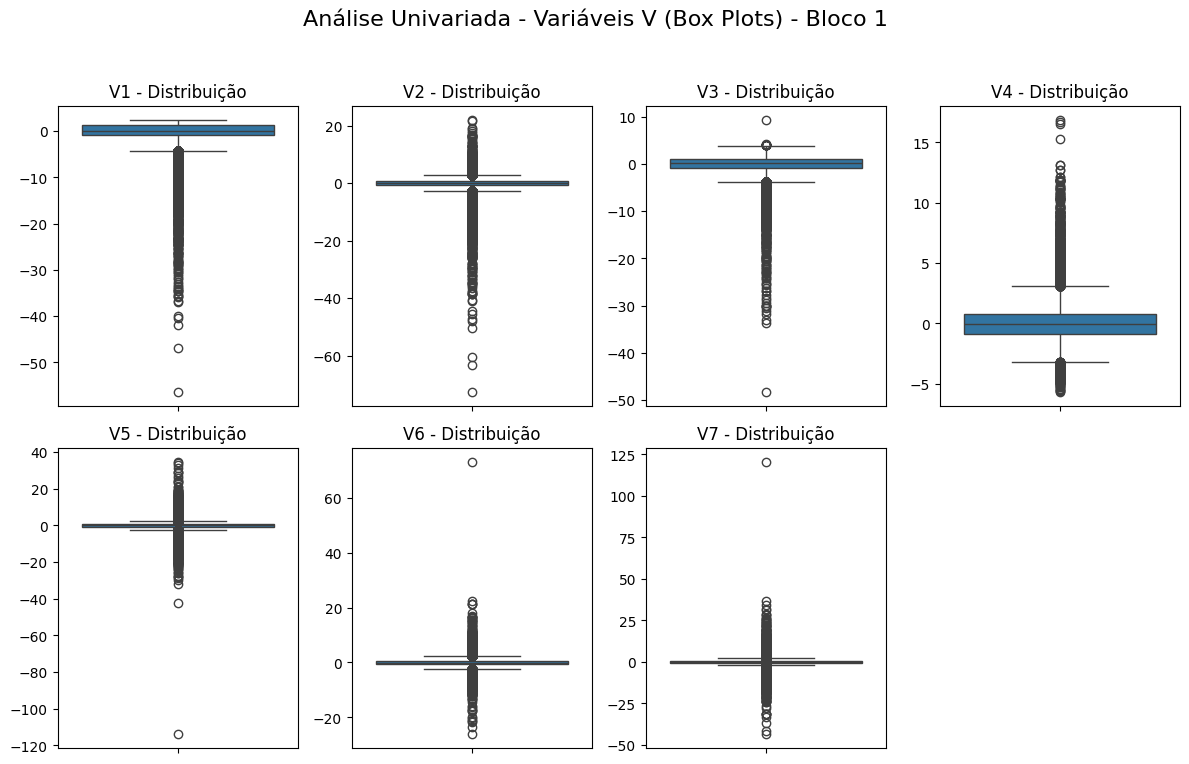

In [ ]:
n_cols = 4 # Fixed number of columns per figure

block_features = v_blocks[0]
n_rows = (len(block_features) + n_cols - 1) // n_cols # Calculate rows needed for the current block

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4)) # Increased height from n_rows * 4 to n_rows * 6
fig.suptitle('Análise Univariada - Variáveis V (Box Plots) - Bloco 1', fontsize=16)

# Flatten axes array for easy iteration if n_rows > 1
axes = axes.flatten() if n_rows > 1 else [axes]

for i, var in enumerate(block_features):
    if var in df.columns:
        sns.boxplot(y=df[var], ax=axes[i])
        axes[i].set_title(f'{var} - Distribuição')
        axes[i].set_ylabel('')

# Hide any unused subplots in the current block's figure
for j in range(len(block_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

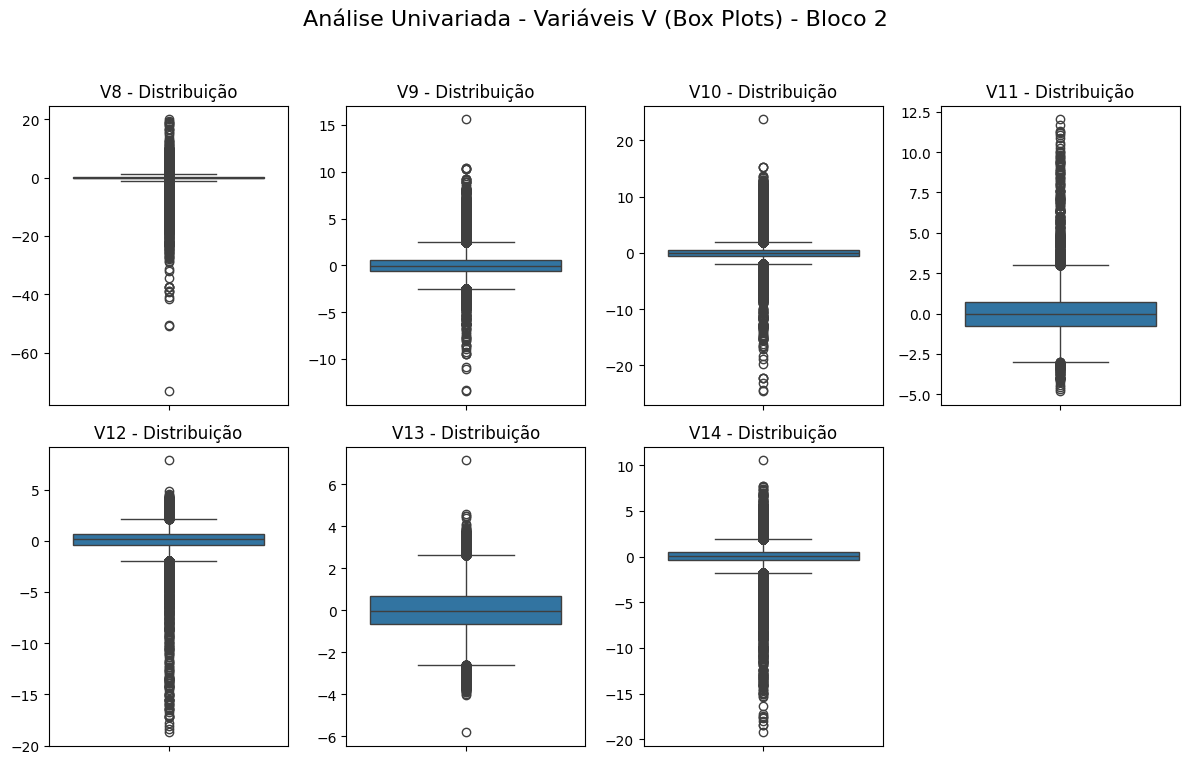

In [ ]:
n_cols = 4 # Fixed number of columns per figure

block_features = v_blocks[1]
n_rows = (len(block_features) + n_cols - 1) // n_cols # Calculate rows needed for the current block

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4)) # Increased height from n_rows * 4 to n_rows * 6
fig.suptitle('Análise Univariada - Variáveis V (Box Plots) - Bloco 2', fontsize=16)

# Flatten axes array for easy iteration if n_rows > 1
axes = axes.flatten() if n_rows > 1 else [axes]

for i, var in enumerate(block_features):
    if var in df.columns:
        sns.boxplot(y=df[var], ax=axes[i])
        axes[i].set_title(f'{var} - Distribuição')
        axes[i].set_ylabel('')

# Hide any unused subplots in the current block's figure
for j in range(len(block_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

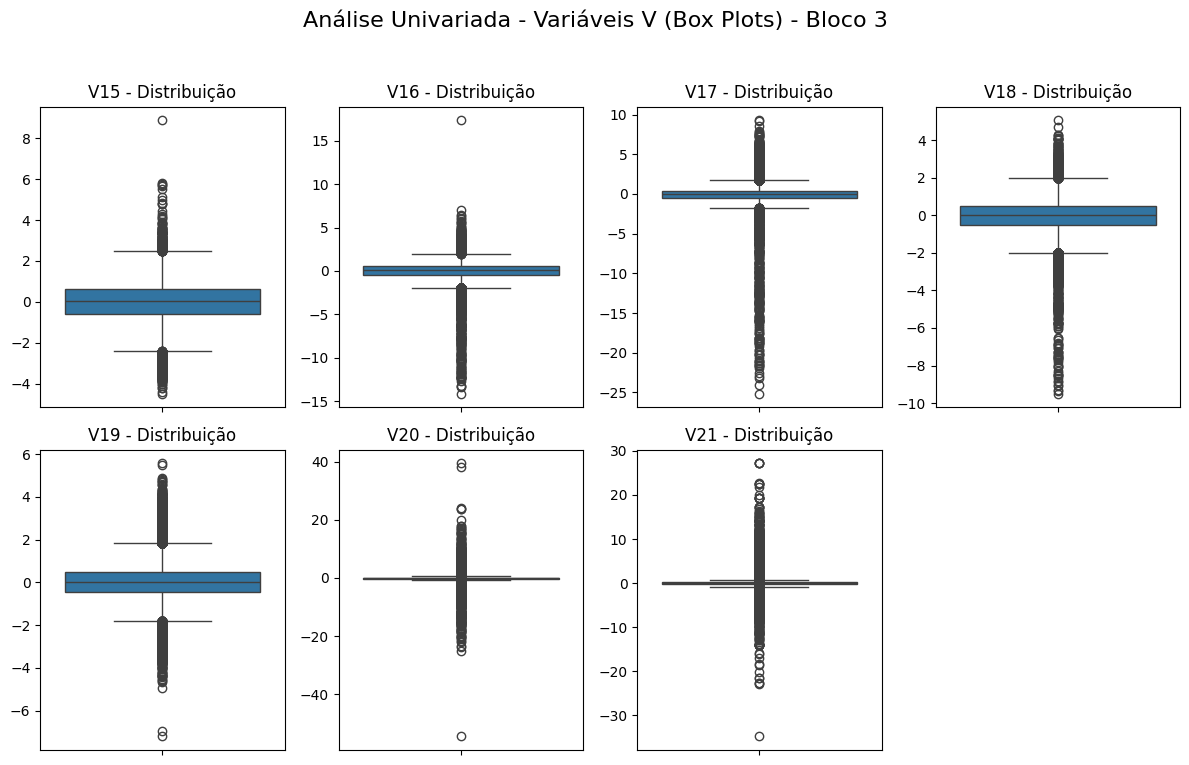

In [ ]:
n_cols = 4 # Fixed number of columns per figure

block_features = v_blocks[2]
n_rows = (len(block_features) + n_cols - 1) // n_cols # Calculate rows needed for the current block

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4)) # Increased height from n_rows * 4 to n_rows * 6
fig.suptitle('Análise Univariada - Variáveis V (Box Plots) - Bloco 3', fontsize=16)

# Flatten axes array for easy iteration if n_rows > 1
axes = axes.flatten() if n_rows > 1 else [axes]

for i, var in enumerate(block_features):
    if var in df.columns:
        sns.boxplot(y=df[var], ax=axes[i])
        axes[i].set_title(f'{var} - Distribuição')
        axes[i].set_ylabel('')

# Hide any unused subplots in the current block's figure
for j in range(len(block_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

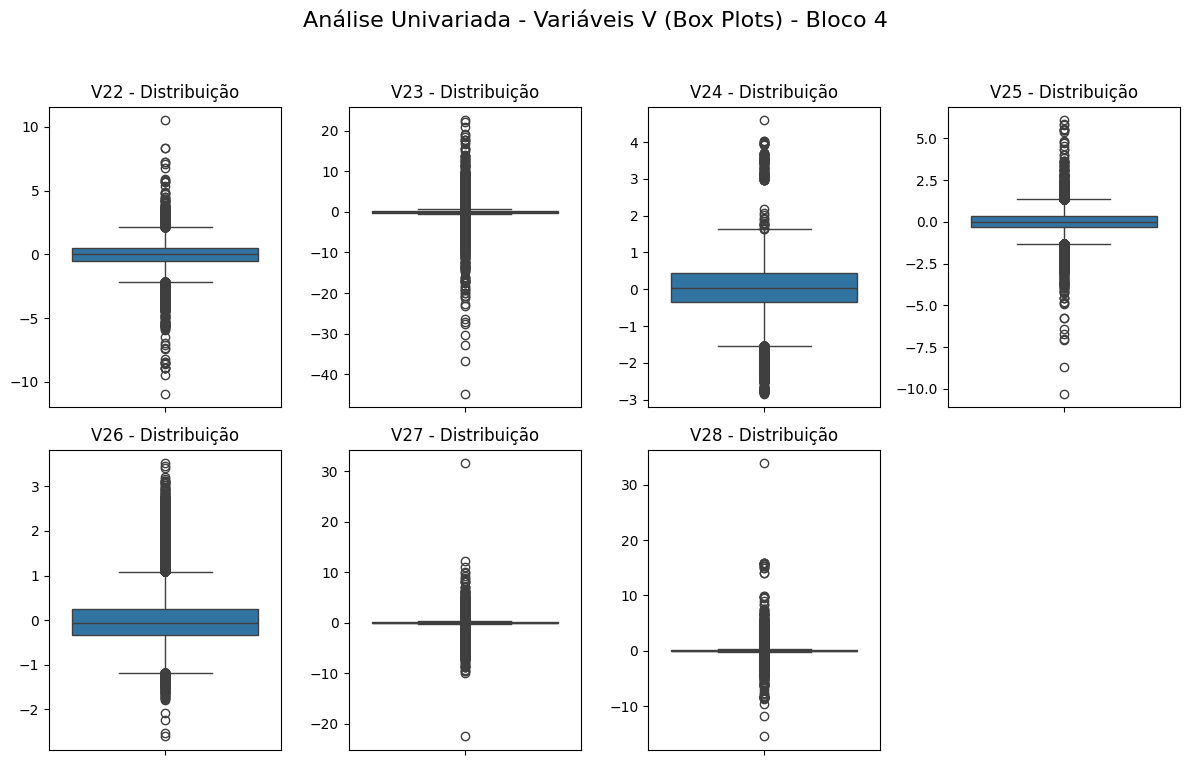

In [ ]:
n_cols = 4 # Fixed number of columns per figure

block_features = v_blocks[3]
n_rows = (len(block_features) + n_cols - 1) // n_cols # Calculate rows needed for the current block

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 4)) # Increased height from n_rows * 4 to n_rows * 6
fig.suptitle('Análise Univariada - Variáveis V (Box Plots) - Bloco 4', fontsize=16)

# Flatten axes array for easy iteration if n_rows > 1
axes = axes.flatten() if n_rows > 1 else [axes]

for i, var in enumerate(block_features):
    if var in df.columns:
        sns.boxplot(y=df[var], ax=axes[i])
        axes[i].set_title(f'{var} - Distribuição')
        axes[i].set_ylabel('')

# Hide any unused subplots in the current block's figure
for j in range(len(block_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Como os valores dos dados dessse dataset são, em sua maioria, valores próximos de zero, a análise do boxplot não fica muito clara, porém isso pode indicar que analisar esses outliers seja um ponto importante para identificação das fraudes, já que em todos os boxplots houveram uma quantidade consierável de outliers


#Análise Bivariada

In [ ]:
corr = df.corr(numeric_only=True)

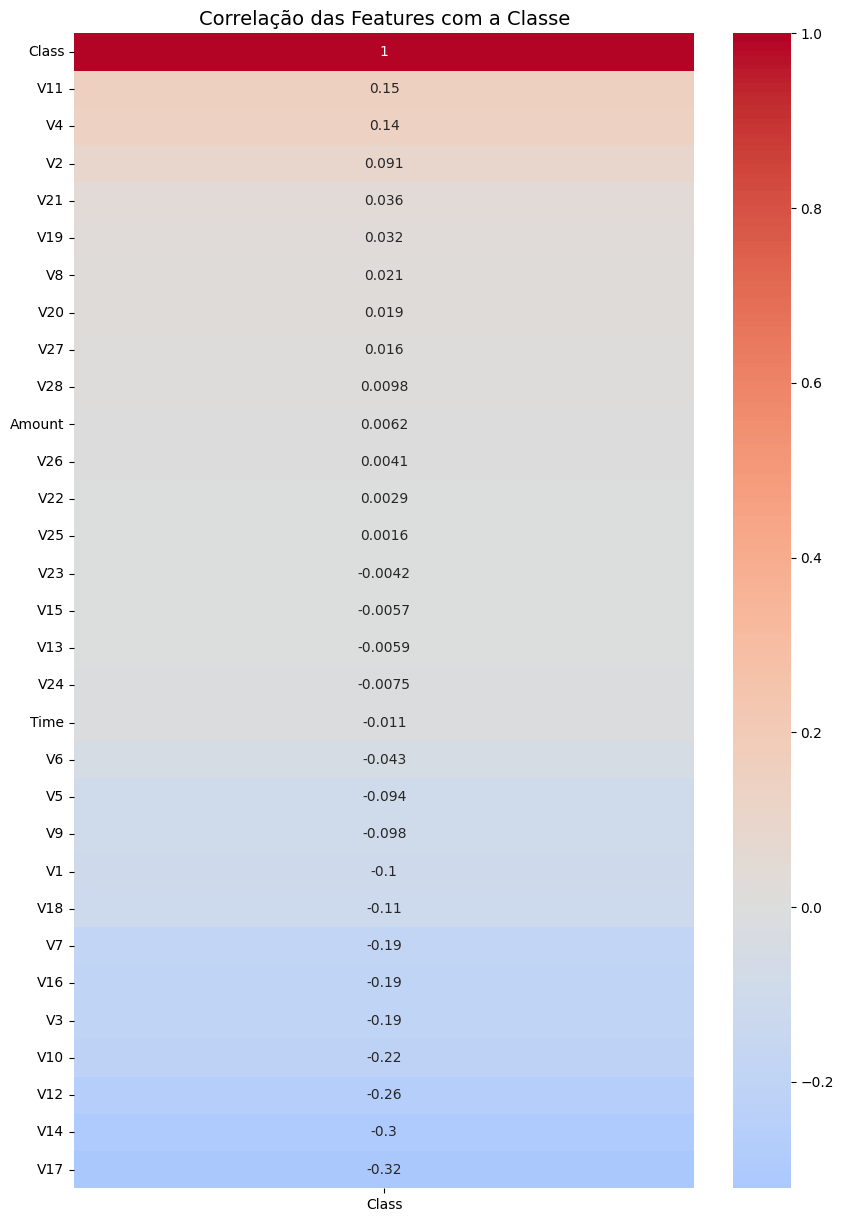

In [ ]:
plt.figure(figsize=(10, 15)) # Increased figure size
sns.heatmap(corr[['Class']].sort_values(by='Class', ascending=False),
            annot=True,
            cmap='coolwarm',
            center=0)
plt.title('Correlação das Features com a Classe', fontsize=14)
plt.show()

Com base nessas correlações focadas na relação entre as features e a variável alvo Class percebe-se que não existem correlações lineares muito fortes entre as variáveis, o que indica que, a princípio, correlações lineares simples não explicam as fraudes

##Análise bivariada dos outliers

Ao fazer a análise univariada percebeu-se que existem alguns outliers dentre as features do tipo V e como o foco do projeto é analisar fraude em transações esses outliers podem ser possíveis indicadores de fraudes

##Gerando os dataframes a serem usados para análise de outliers

* df_normal: dataframe que possui os valores que não são outliers com base nos percentiles 0.75 e 0.25
* df_outlier: dataframe que possui os valores que são outliers com base nos percentiles 0.75 e 0.25
* df_ex_outlier: dataframe que possui os valores que são outliers com base nos percentiles 0.95 e 0.05

In [ ]:
#Gerar um dataframe com os valores considerados outliers nas features do tipo V

outlier_rows = pd.Series([False] * len(df), index=df.index)

for var in v_features:
    if var in df.columns:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_rows = outlier_rows | ((df[var] < lower_bound) | (df[var] > upper_bound))

df_outlier = df[outlier_rows].copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"Outliers DataFrame shape: {df_outlier.shape}")

display(df_outlier.head())

Original DataFrame shape: (227845, 31)
Outliers DataFrame shape: (102923, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,161919.0,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,7.32,0
1,124477.0,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,2.99,0
2,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,175.10,0
4,59359.0,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,86.10,0
5,79404.0,1.320449,-1.560991,-0.154324,-1.806184,-0.831334,0.877820,-1.212515,0.246020,-1.747897,...,-0.346511,-0.941239,-0.104322,-1.790279,0.184198,-0.299018,0.025862,0.016056,125.29,0


In [ ]:
#Gerar um dataframe com os valores considerados outliers extremos nas features do tipo V

ex_outlier_rows = pd.Series([False] * len(df), index=df.index)

for var in v_features:
    if var in df.columns:
        Q1 = df[var].quantile(0.05)
        Q3 = df[var].quantile(0.95)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        ex_outlier_rows = ex_outlier_rows | ((df[var] < lower_bound) | (df[var] > upper_bound))

df_ex_outlier = df[ex_outlier_rows].copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"Outliers DataFrame shape: {df_ex_outlier.shape}")

display(df_ex_outlier.head())

Original DataFrame shape: (227845, 31)
Outliers DataFrame shape: (9710, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
2,41191.0,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,175.10,0
28,84871.0,-1.492430,1.369384,2.062786,0.034305,-0.953419,0.890449,-1.232362,-3.820947,0.659150,...,3.797797,-1.070306,0.438148,0.491504,-0.186784,0.251788,0.057627,-0.166534,19.53,0
78,140481.0,-5.039282,-4.078033,-1.113411,0.642563,2.942036,-2.252946,-0.992941,0.443622,0.307315,...,-0.237562,-0.889443,-1.745110,0.763331,-0.307690,-0.150343,1.076696,-1.246624,219.34,0
80,142515.0,-9.701692,-12.687685,1.363320,0.091666,5.412188,-5.177345,-5.086865,0.222469,-0.318330,...,-0.082970,-0.051699,0.425639,-0.034243,0.706110,0.030886,0.945238,0.898032,763.25,0
81,103074.0,-1.496049,2.379089,-1.324483,-0.283978,0.335877,0.250029,-1.081103,-4.653228,1.617070,...,4.759714,-0.767915,0.488320,-0.716509,-0.325414,-0.181040,-0.130056,-0.164065,12.56,0


In [ ]:
#Gerar um dataframe com os valores considerados outliers nas features do tipo V

is_not_outlier_mask = pd.Series(True, index=df.index)

for var in v_features:
    if var in df.columns:
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        is_not_outlier_mask = is_not_outlier_mask & ((df[var] >= lower_bound) & (df[var] <= upper_bound))

df_normal = df[is_not_outlier_mask].copy()

print(f"Original DataFrame shape: {df.shape}")
print(f"Normal DataFrame (without outliers in any V feature) shape: {df_normal.shape}")

df_normal.head()

Original DataFrame shape: (227845, 31)
Normal DataFrame (without outliers in any V feature) shape: (124922, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
3,132624.0,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,6.10,0
9,148508.0,1.973973,-0.404605,-0.222072,0.534479,-0.830112,-0.626462,-0.595997,-0.066845,1.465829,...,0.194876,0.822169,0.120061,0.072218,-0.097635,-0.215837,0.041900,-0.036105,9.99,0
10,91069.0,-0.719954,1.121666,0.712323,-0.821493,1.152592,-0.566300,0.810576,-0.023018,1.057423,...,-0.248931,-0.359137,-0.501620,-0.654631,1.072223,-0.308467,0.145645,-0.000070,4.91,0
12,160989.0,1.995704,-0.195623,-1.633425,-0.122263,0.241660,-0.915830,0.311364,-0.235773,0.322583,...,-0.101733,-0.342704,0.160501,-0.485067,-0.098479,-0.148187,-0.066178,-0.069471,40.00,0
13,80035.0,-0.784263,0.695361,1.794515,0.043209,-0.224788,-0.183185,0.616886,0.178622,0.212933,...,-0.324375,-0.879240,-0.151231,-0.163026,0.327231,0.267749,0.238734,0.120400,47.15,0


In [ ]:
frauds_outlier = (df_outlier['Class'] == 1).sum()
print(f"Número de transações fraudulentas em df_outlier: {frauds_outlier}")

Número de transações fraudulentas em df_outlier: 383


In [ ]:
frauds_normal = (df_normal['Class'] == 1).sum()
print(f"Número de transações fraudulentas em df_normal: {frauds_normal}")

Número de transações fraudulentas em df_normal: 11


In [ ]:
frauds_ex_outlier = (df_ex_outlier['Class'] == 1).sum()
print(f"Número de transações fraudulentas em df_ex_outlier: {frauds_ex_outlier}")

Número de transações fraudulentas em df_ex_outlier: 310


In [ ]:
total_frauds = df['Class'].sum()

print(f"Número de transações fraudulentas no DataFrame original: {total_frauds}")
print(f"Número de transações fraudulentas em df_outlier: {frauds_outlier}")
print(f"Número de transações fraudulentas em df_ex_outlier: {frauds_ex_outlier}")
print(f"Número de transações fraudulentas em df_normal: {frauds_normal}")

print(f"\nProporção de fraudes em df_outlier: {frauds_outlier / total_frauds:.2%}")
print(f"Proporção de fraudes em df_normal: {frauds_normal / total_frauds:.2%}")
print(f"Proporção de fraudes em df_ex_outlier: {frauds_ex_outlier / total_frauds:.2%}")

# Calculate the sum of frauds from both dataframes to check if they cover all original frauds
sum_of_frauds_in_subsets = frauds_outlier + frauds_normal
print(f"\nSoma de fraudes em df_outlier e df_normal: {sum_of_frauds_in_subsets}")
print(f"Isso representa {sum_of_frauds_in_subsets / total_frauds:.2%} do total de fraudes originais.")

Número de transações fraudulentas no DataFrame original: 394
Número de transações fraudulentas em df_outlier: 383
Número de transações fraudulentas em df_ex_outlier: 310
Número de transações fraudulentas em df_normal: 11

Proporção de fraudes em df_outlier: 97.21%
Proporção de fraudes em df_normal: 2.79%
Proporção de fraudes em df_ex_outlier: 78.68%

Soma de fraudes em df_outlier e df_normal: 394
Isso representa 100.00% do total de fraudes originais.


Analisando quantos casoso de fraude estão presentes nos outliers, tanto no normal quanto no extremo, pode ser um bom indício de que quando ocorre uma fraude, normalmente está associada a algum outlier

##Comparação entre os outliers normais(quantiles usados: 0.25 e 0.75) e o dataframe com todos os dados

In [ ]:
corr_outlier = df_outlier.corr(numeric_only=True)

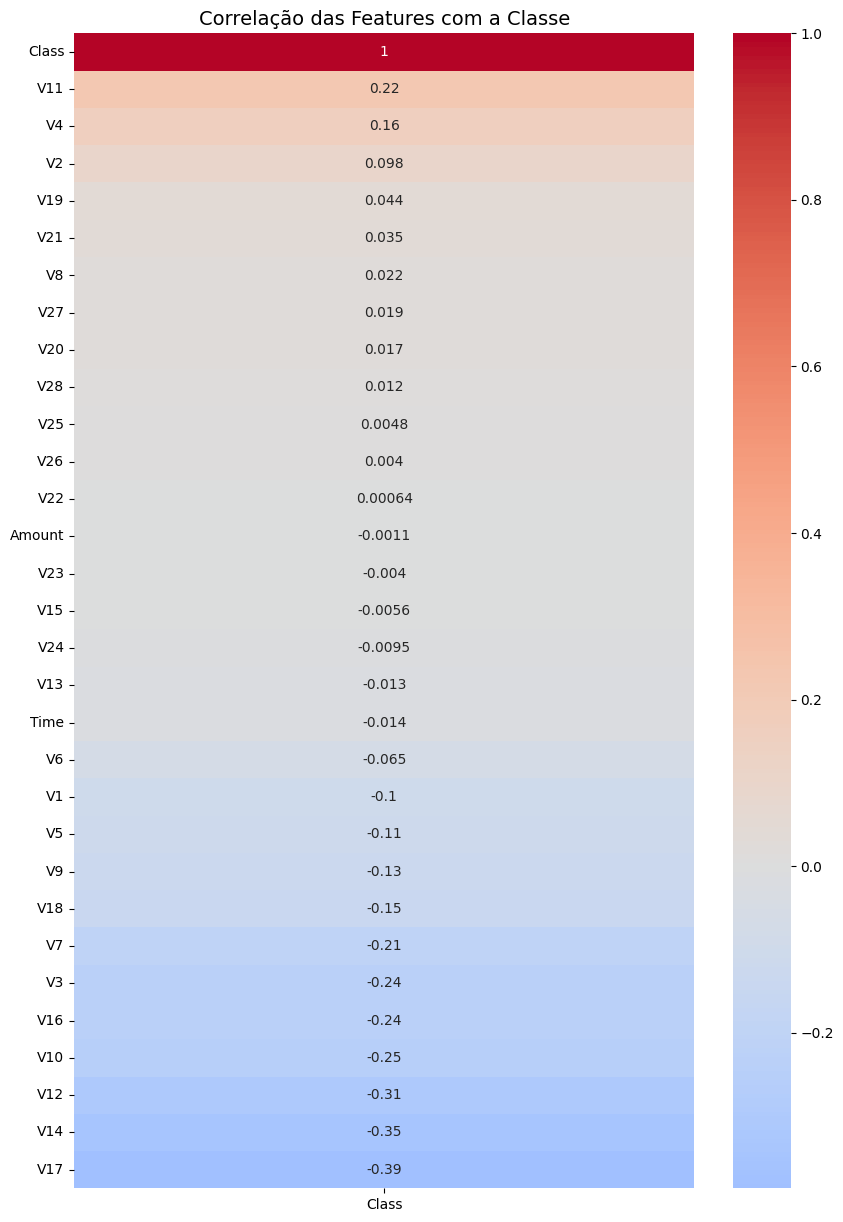

In [ ]:
plt.figure(figsize=(10, 15)) # Increased figure size
sns.heatmap(corr_outlier[['Class']].sort_values(by='Class', ascending=False),
            annot=True,
            cmap='coolwarm',
            center=0)
plt.title('Correlação das Features com a Classe', fontsize=14)
plt.show()

In [ ]:
corr_class_original = df.corr(numeric_only=True)['Class']
print("Correlations with Class (Original DataFrame):")
print(corr_class_original.head())

Correlations with Class (Original DataFrame):
Time   -0.010564
V1     -0.100041
V2      0.090586
V3     -0.194135
V4      0.135014
Name: Class, dtype: float64


In [ ]:
corr_class_outlier = corr_outlier['Class']

diff_corr_class = (corr_class_original - corr_class_outlier).abs().sort_values(ascending=False)

print("\nTop 5 features with largest absolute difference in correlation with Class:")
print(diff_corr_class.head(5))


Top 5 features with largest absolute difference in correlation with Class:
V11    0.066354
V17    0.064751
V16    0.045339
V12    0.045029
V14    0.044350
Name: Class, dtype: float64


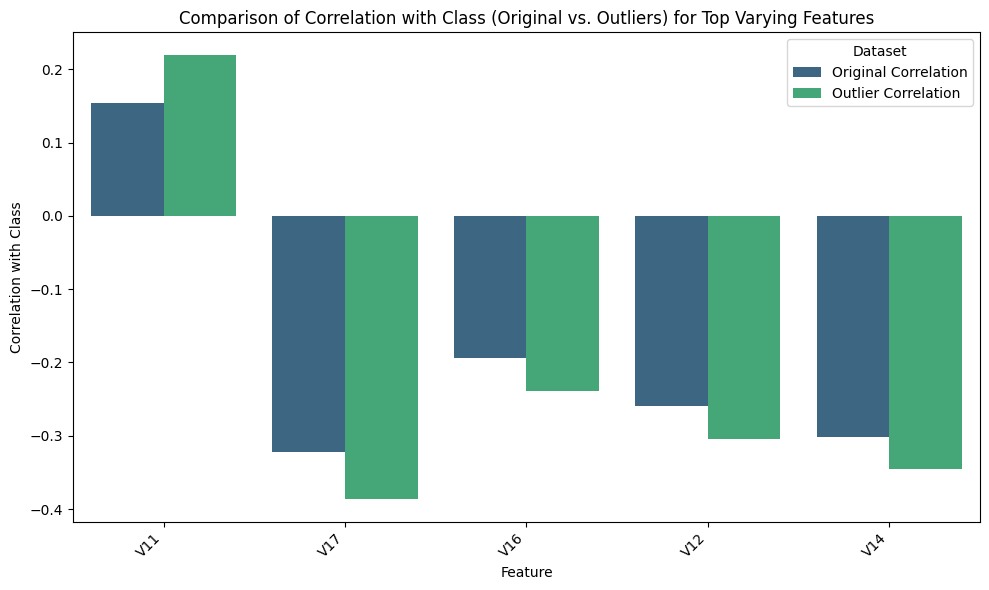

In [ ]:
top_class_features = diff_corr_class.head(5).index

plot_data_class = pd.DataFrame({
    'Feature': top_class_features,
    'Original Correlation': corr_class_original.loc[top_class_features],
    'Outlier Correlation': corr_class_outlier.loc[top_class_features]
})

plot_data_class_melted = plot_data_class.melt(id_vars='Feature', var_name='Dataset', value_name='Correlation')

plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Correlation', hue='Dataset', data=plot_data_class_melted, palette='viridis')
plt.title('Comparison of Correlation with Class (Original vs. Outliers) for Top Varying Features')
plt.ylabel('Correlation with Class')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Após esse gráfico, é possível perceber que nos top 5 casos que houveram diferença na correlação linear, serviram para corroborar o que já foi observado, features que tendem a possuir mais relação com fraude continuam tendendo a ter mais relação e features que não tendem continuam sem essa tendência

##Acrescentando um dataframe somente com dados que não são outliers(tomando como base os outliers normais anteriores)

In [ ]:
corr_normal = df_normal.corr(numeric_only=True)
corr_class_normal = corr_normal['Class']

print("Correlations with Class (Normal DataFrame):")
print(corr_class_normal.head())

Correlations with Class (Normal DataFrame):
Time   -0.006507
V1     -0.001671
V2      0.008659
V3      0.000804
V4      0.011233
Name: Class, dtype: float64


In [ ]:
all_corr_class = pd.DataFrame({
    'Original': corr_class_original,
    'Outlier': corr_class_outlier,
    'Normal': corr_class_normal
})

print("Consolidated Correlations with Class (first 5 rows):")
print(all_corr_class.head())

Consolidated Correlations with Class (first 5 rows):
      Original   Outlier    Normal
Time -0.010564 -0.013591 -0.006507
V1   -0.100041 -0.104519 -0.001671
V2    0.090586  0.097957  0.008659
V3   -0.194135 -0.238359  0.000804
V4    0.135014  0.164452  0.011233


In [ ]:
max_diff_corr_class = all_corr_class.max(axis=1) - all_corr_class.min(axis=1)
top_class_features_max_diff = max_diff_corr_class.nlargest(5).index

print("\nTop 5 features with largest difference in correlation with Class across datasets:")
print(all_corr_class.loc[top_class_features_max_diff])


Top 5 features with largest difference in correlation with Class across datasets:
     Original   Outlier    Normal
V17 -0.321937 -0.386688  0.010463
V14 -0.301054 -0.345405 -0.012576
V12 -0.259989 -0.305018 -0.004973
V10 -0.217894 -0.251066 -0.004564
V16 -0.193826 -0.239164  0.006113


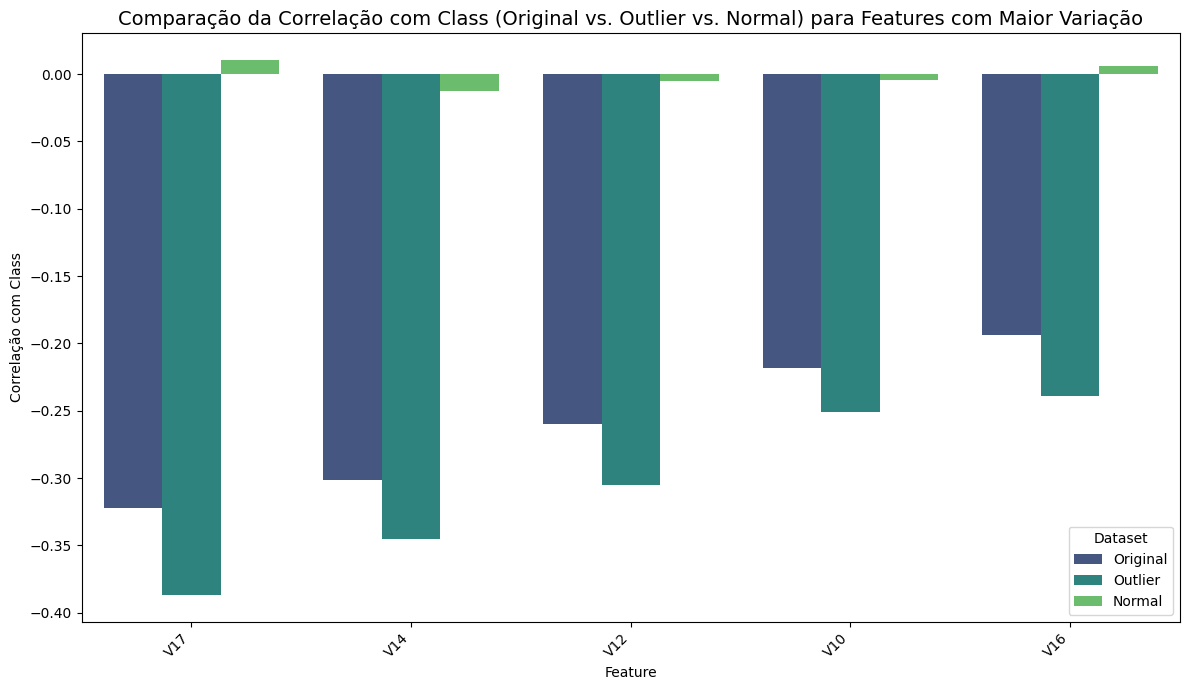

In [ ]:
plot_data_class_all = all_corr_class.loc[top_class_features_max_diff].reset_index().rename(columns={'index': 'Feature'})
plot_data_class_melted_all = plot_data_class_all.melt(id_vars='Feature', var_name='Dataset', value_name='Correlation')

plt.figure(figsize=(12, 7))
sns.barplot(x='Feature', y='Correlation', hue='Dataset', data=plot_data_class_melted_all, palette='viridis')
plt.title('Comparação da Correlação com Class (Original vs. Outlier vs. Normal) para Features com Maior Variação', fontsize=14)
plt.ylabel('Correlação com Class')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Apóos esse gráfico percebe-se que dados não considerados outliers, levando em consideração os percentiles 0.75 e 0.25, não possuem muita relação linear nem positiva nem positiva.

##Análise com um dataframe de outliers extremos(percentile 0.95 e 0.05)

##Conclusão

A princípio os outliers são bons indicativos de transações fraudulentas fraudulentos

In [ ]:
def analyze_outliers_by_feature(df, feature, method='standard'):
    """
    Calculates outlier bounds for a given feature, identifies outlier transactions,
    and counts fraudulent transactions among them.

    Args:
        df (pd.DataFrame): The input DataFrame.
        feature (str): The name of the 'V' feature to analyze.
        method (str, optional): The method for calculating quartiles.
                                 'standard' uses 25th and 75th percentiles.
                                 'extreme' uses 5th and 95th percentiles.
                                 Defaults to 'standard'.

    Returns:
        dict: A dictionary containing total_outliers, frauds_in_outliers,
              and fraud_proportion.
    """

    if method == 'standard':
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
    elif method == 'extreme':
        Q1 = df[feature].quantile(0.05)
        Q3 = df[feature].quantile(0.95)
    else:
        raise ValueError("Method must be 'standard' or 'extreme'")

    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_df = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)].copy()

    total_outliers = len(outliers_df)
    frauds_in_outliers = (outliers_df['Class'] == 1).sum()

    fraud_proportion = frauds_in_outliers / total_outliers if total_outliers > 0 else 0

    return {
        'total_outliers': total_outliers,
        'frauds_in_outliers': frauds_in_outliers,
        'fraud_proportion': fraud_proportion
    }

print("Function 'analyze_outliers_by_feature' defined successfully.")

Function 'analyze_outliers_by_feature' defined successfully.


In [ ]:
results_iqr = []
for var in v_features:
    result = analyze_outliers_by_feature(df, var, method='standard')
    results_iqr.append({
        'Feature': var,
        'Method': 'Standard IQR',
        'Total Outliers': result['total_outliers'],
        'Frauds in Outliers': result['frauds_in_outliers'],
        'Fraud Proportion': result['fraud_proportion']
    })

fraud_proportion_iqr = pd.DataFrame(results_iqr)
print("DataFrame 'fraud_proportion_iqr' created successfully for standard IQR outliers.")
display(fraud_proportion_iqr.head())

DataFrame 'fraud_proportion_iqr' created successfully for standard IQR outliers.


,Feature,Method,Total Outliers,Frauds in Outliers,Fraud Proportion
0,V1,Standard IQR,5639,136,0.024118
1,V2,Standard IQR,10774,195,0.018099
2,V3,Standard IQR,2689,250,0.092971
3,V4,Standard IQR,8958,258,0.028801
4,V5,Standard IQR,9805,165,0.016828


In [ ]:
results_extreme = []
for var in v_features:
    result = analyze_outliers_by_feature(df, var, method='extreme')
    results_extreme.append({
        'Feature': var,
        'Method': 'Extreme IQR',
        'Total Outliers': result['total_outliers'],
        'Frauds in Outliers': result['frauds_in_outliers'],
        'Fraud Proportion': result['fraud_proportion']
    })

fraud_proportion_extreme = pd.DataFrame(results_extreme)
print("DataFrame 'fraud_proportion_extreme' created successfully for extreme IQR outliers.")
display(fraud_proportion_extreme.head())

DataFrame 'fraud_proportion_extreme' created successfully for extreme IQR outliers.


,Feature,Method,Total Outliers,Frauds in Outliers,Fraud Proportion
0,V1,Extreme IQR,728,65,0.089286
1,V2,Extreme IQR,1228,54,0.043974
2,V3,Extreme IQR,279,92,0.329749
3,V4,Extreme IQR,51,24,0.470588
4,V5,Extreme IQR,609,71,0.116585


In [ ]:
print("\nFraud Proportion using Standard IQR Outliers:")
display(fraud_proportion_iqr)


Fraud Proportion using Standard IQR Outliers:


,Feature,Method,Total Outliers,Frauds in Outliers,Fraud Proportion
0,V1,Standard IQR,5639,136,0.024118
1,V2,Standard IQR,10774,195,0.018099
2,V3,Standard IQR,2689,250,0.092971
3,V4,Standard IQR,8958,258,0.028801
4,V5,Standard IQR,9805,165,0.016828
5,V6,Standard IQR,18273,110,0.006020
6,V7,Standard IQR,7112,239,0.033605
7,V8,Standard IQR,19214,190,0.009889
8,V9,Standard IQR,6649,181,0.027222
9,V10,Standard IQR,7558,318,0.042075


In [ ]:
print("\nFraud Proportion using Extreme IQR Outliers:")
display(fraud_proportion_extreme)


Fraud Proportion using Extreme IQR Outliers:


,Feature,Method,Total Outliers,Frauds in Outliers,Fraud Proportion
0,V1,Extreme IQR,728,65,0.089286
1,V2,Extreme IQR,1228,54,0.043974
2,V3,Extreme IQR,279,92,0.329749
3,V4,Extreme IQR,51,24,0.470588
4,V5,Extreme IQR,609,71,0.116585
5,V6,Extreme IQR,118,0,0.000000
6,V7,Extreme IQR,1124,125,0.111210
7,V8,Extreme IQR,3188,80,0.025094
8,V9,Extreme IQR,98,22,0.224490
9,V10,Extreme IQR,981,146,0.148828


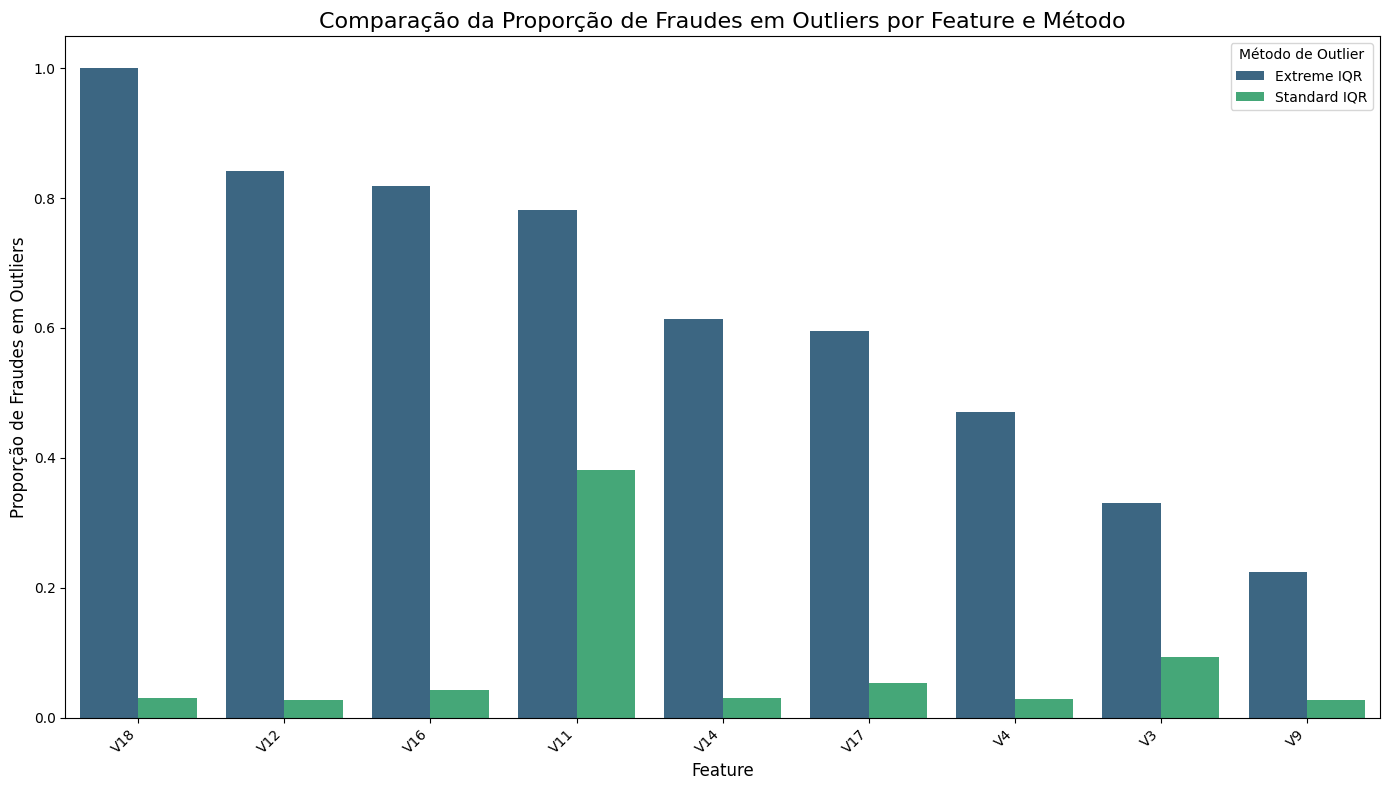

In [ ]:
all_fraud_proportions = pd.concat([fraud_proportion_iqr, fraud_proportion_extreme])

top_features_by_fraud = all_fraud_proportions.sort_values(by='Fraud Proportion', ascending=False).head(10)['Feature'].unique()

plot_df = all_fraud_proportions[all_fraud_proportions['Feature'].isin(top_features_by_fraud)]

plot_df = plot_df.sort_values(by=['Fraud Proportion'], ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x='Feature', y='Fraud Proportion', hue='Method', data=plot_df, palette='viridis')
plt.title('Comparação da Proporção de Fraudes em Outliers por Feature e Método', fontsize=16)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Proporção de Fraudes em Outliers', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Método de Outlier')
plt.tight_layout()
plt.show()